In [1]:
# =========================================================
# CELL 1: IMPORTS AND SETUP
# =========================================================

# Import of the needed libraries
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns        # Statistical data visualization

# Set plotting style for better looking visuals
sns.set_style("whitegrid")   # White background with grid lines
plt.rcParams['figure.figsize'] = (12, 8)  # Default figure size (width, height)

In [10]:
# =========================================================
# CELL 2: LOAD DATA AND OVERVIEW
# =========================================================

# Load the dataset and remove the identifier column
df = pd.read_csv("downtilt_dataset_300.csv")  # Read CSV file into DataFrame
df = df.drop(columns=["site_id"])  # Drop site_id - not useful for prediction

# Print dataset overview for initial exploration
print("*"*60)
print("DATASET OVERVIEW")
print("*"*60)
print(f"Shape: {df.shape}")  # Display (rows, columns)
print("*"*60)
print(f"Columns: {df.columns.tolist()}")  # List all column names
print("*"*60)
print("MISSING VALUES")
print("*"*60)
print(f"Missing values:\n{df.isnull().sum()}")  # Check for missing data in each column
print("*"*60)
print(f"Describe: {df.describe()}\n")  # Display (rows, columns)
print("DATA TYPES")
print(f"\nData types:\n{df.dtypes}")  # Verify numeric vs categorical columns

************************************************************
DATASET OVERVIEW
************************************************************
Shape: (300, 17)
************************************************************
Columns: ['site_height_m', 'antenna_height_m', 'frequency_mhz', 'bandwidth_mhz', 'tx_power_dbm', 'antenna_gain_dbi', 'inter_site_distance_km', 'traffic_load_pct', 'coverage_km2', 'capacity_utilization_pct', 'avg_tput_mbps', 'rsrp_dbm', 'sinr_db', 'user_density', 'fault_rate', 'environment', 'downtilt_deg']
************************************************************
MISSING VALUES
************************************************************
Missing values:
site_height_m               0
antenna_height_m            0
frequency_mhz               0
bandwidth_mhz               0
tx_power_dbm                0
antenna_gain_dbi            0
inter_site_distance_km      0
traffic_load_pct            0
coverage_km2                0
capacity_utilization_pct    0
avg_tput_mbps         

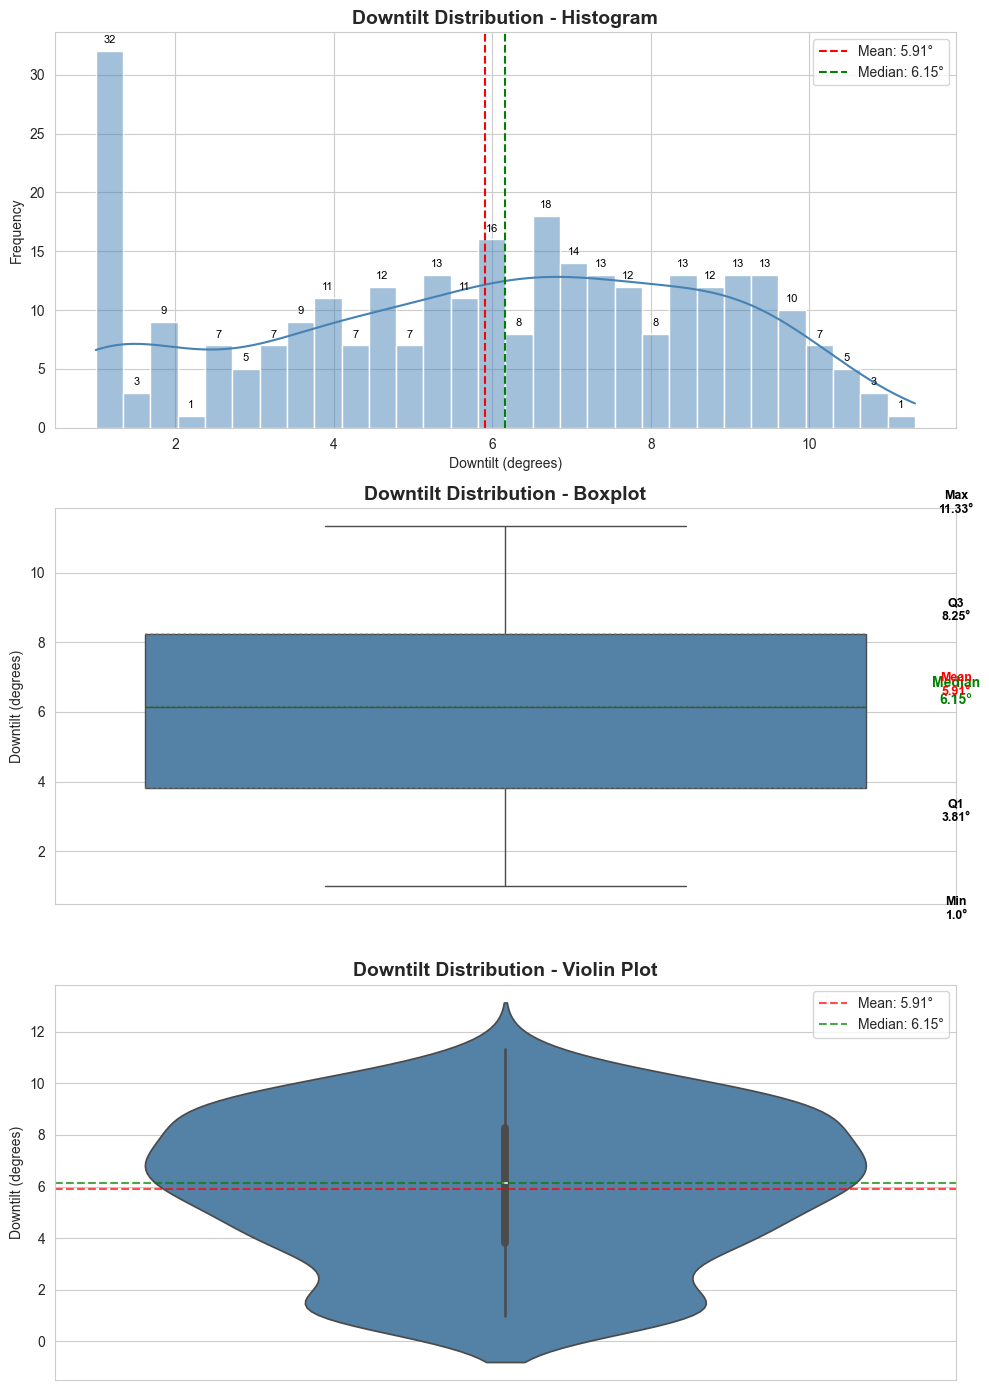


📊 Downtilt Statistics:
count    300.000000
mean       5.909467
std        2.817133
min        1.000000
25%        3.810000
50%        6.155000
75%        8.252500
max       11.330000
Name: downtilt_deg, dtype: float64

📊 Additional Statistics:
Variance: 7.9362
Skewness: -0.2650
Kurtosis: -0.9610
Range: 10.33°


In [13]:
# =========================================================
# CELL 3: TARGET VARIABLE - DOWNTILT DISTRIBUTION
# =========================================================

# Analyze the distribution of downtilt_deg (the target variable we want to predict)
# Three visualizations: histogram (shape), boxplot (spread/outliers), violin (density)

fig, axes = plt.subplots(3, 1, figsize=(10, 14))  # Create 3 rows, 1 column of plots

# -------------------------------------------------------------------------
# Plot 1: Histogram with KDE
# -------------------------------------------------------------------------
ax = axes[0]
sns.histplot(df['downtilt_deg'], kde=True, bins=30, ax=ax, color='steelblue')

# Add vertical lines for mean and median
ax.axvline(df['downtilt_deg'].mean(), color='red', linestyle='--', 
           label=f'Mean: {df["downtilt_deg"].mean():.2f}°')
ax.axvline(df['downtilt_deg'].median(), color='green', linestyle='--', 
           label=f'Median: {df["downtilt_deg"].median():.2f}°')
ax.set_title('Downtilt Distribution - Histogram', fontsize=14, fontweight='bold')
ax.set_xlabel('Downtilt (degrees)')
ax.set_ylabel('Frequency')
ax.legend()

# Add value labels on histogram bars
counts, bins = np.histogram(df['downtilt_deg'], bins=30)
for count, bin_edge in zip(counts, bins[:-1]):
    if count > 0:
        ax.text(bin_edge + (bins[1]-bins[0])/2, count + 0.5, str(count), 
                ha='center', va='bottom', fontsize=8, color='black')

# -------------------------------------------------------------------------
# Plot 2: Boxplot with Values
# -------------------------------------------------------------------------
ax = axes[1]
sns.boxplot(y=df['downtilt_deg'], ax=ax, color='steelblue')
ax.set_title('Downtilt Distribution - Boxplot', fontsize=14, fontweight='bold')
ax.set_ylabel('Downtilt (degrees)')

# Calculate statistics for annotations
q1 = df['downtilt_deg'].quantile(0.25)
q2 = df['downtilt_deg'].median()
q3 = df['downtilt_deg'].quantile(0.75)
min_val = df['downtilt_deg'].min()
max_val = df['downtilt_deg'].max()
mean_val = df['downtilt_deg'].mean()

# Add text annotations for each statistical value
ax.text(0.5, min_val - 0.3, f'Min\n{min_val:.1f}°', ha='center', va='top', 
        fontsize=9, fontweight='bold', color='black')
ax.text(0.5, q1 - 0.3, f'Q1\n{q1:.2f}°', ha='center', va='top', 
        fontsize=9, fontweight='bold', color='black')
ax.text(0.5, q2, f'Median\n{q2:.2f}°', ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='green')
ax.text(0.5, q3 + 0.3, f'Q3\n{q3:.2f}°', ha='center', va='bottom', 
        fontsize=9, fontweight='bold', color='black')
ax.text(0.5, max_val + 0.3, f'Max\n{max_val:.2f}°', ha='center', va='bottom', 
        fontsize=9, fontweight='bold', color='black')
ax.text(0.5, mean_val + 0.5, f'Mean\n{mean_val:.2f}°', ha='center', va='bottom', 
        fontsize=9, fontweight='bold', color='red')

# Annotate quartile lines directly on the plot
ax.axhline(y=q1, color='gray', linestyle=':', alpha=0.5, xmin=0.1, xmax=0.9)
ax.axhline(y=q2, color='green', linestyle=':', alpha=0.5, xmin=0.1, xmax=0.9)
ax.axhline(y=q3, color='gray', linestyle=':', alpha=0.5, xmin=0.1, xmax=0.9)

# -------------------------------------------------------------------------
# Plot 3: Violin Plot
# -------------------------------------------------------------------------
ax = axes[2]
sns.violinplot(y=df['downtilt_deg'], ax=ax, color='steelblue')
ax.set_title('Downtilt Distribution - Violin Plot', fontsize=14, fontweight='bold')
ax.set_ylabel('Downtilt (degrees)')

# Add mean and median lines on violin plot
ax.axhline(y=mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}°')
ax.axhline(y=q2, color='green', linestyle='--', alpha=0.7, label=f'Median: {q2:.2f}°')
ax.legend()

plt.tight_layout()
plt.show()

# Print summary statistics for the target variable
print("\n📊 Downtilt Statistics:")
print(df['downtilt_deg'].describe())

# Additional statistics
print("\n📊 Additional Statistics:")
print(f"Variance: {df['downtilt_deg'].var():.4f}")
print(f"Skewness: {df['downtilt_deg'].skew():.4f}")
print(f"Kurtosis: {df['downtilt_deg'].kurtosis():.4f}")
print(f"Range: {df['downtilt_deg'].max() - df['downtilt_deg'].min():.2f}°")

### 📊 Downtilt Distribution

- **Shape:** Right-skewed (long tail toward higher angles)
- **Peak:** Most towers at 5-6° (suburban range)
- **Range:** 1° (rural) to 11°+ (dense urban)  
- **Mean:** 5.91° | **Median:** 6.15° (mean < median confirms right skew)
- **Interpretation:** Urban towers drive the high end; rural towers at low end

### 📊 Downtilt Distribution - Boxplot & Violin Plot

| Metric | Value | Meaning |
|--------|-------|---------|
| **Median** | 6.15° | Typical tower downtilt |
| **IQR** | 3.8° - 8.25° | Middle 50% of towers |
| **Range** | 1.0° - 11.33° | Rural to dense urban extremes |
| **Skew** | Right-skewed | More towers at lower end, tail toward high urban values |

**Key Insight:** The violin plot reveals a multimodal distribution, reflecting distinct downtilt patterns for different environments (rural, suburban, urban).

C:\Users\admin\AppData\Local\Temp\ipykernel_2208\3510994539.py:46: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\3510994539.py:46: UserWarning: Glyph 127960 (\N{HOUSE BUILDINGS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\3510994539.py:46: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\3510994539.py:46: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127960 (\N{HOUSE BUILDINGS}) missing from font(s) Arial.
  f

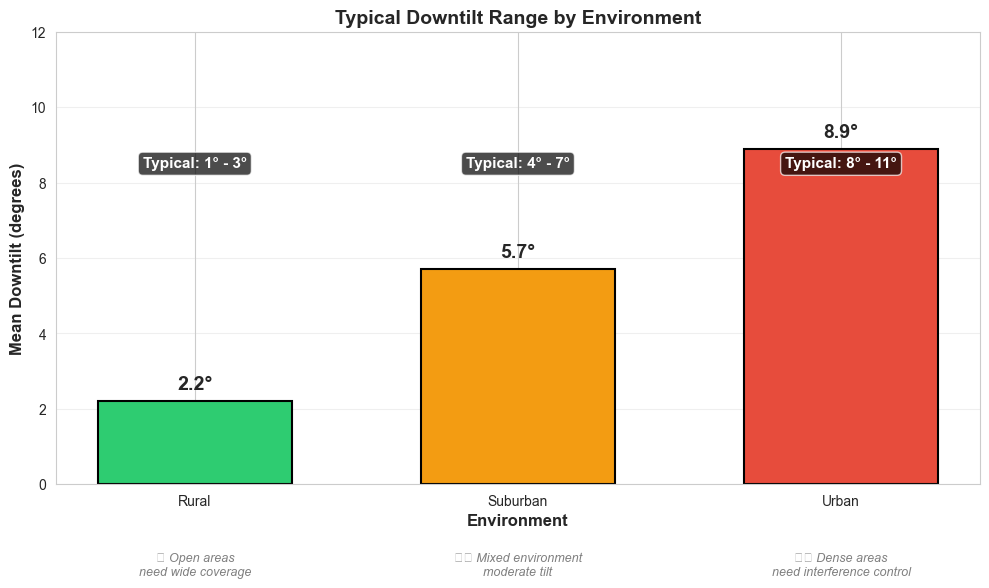

In [14]:
# =========================================================
# ENVIRONMENT DOWNTILT BREAKDOWN - SIMPLE VERSION
# =========================================================

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Summary data
summary_data = pd.DataFrame({
    'Environment': ['Rural', 'Suburban', 'Urban'],
    'Typical Downtilt': ['1° - 3°', '4° - 7°', '8° - 11°'],
    'Mean Downtilt': [2.2, 5.7, 8.9],
    'Reason': ['🌳 Open areas\nneed wide coverage', 
               '🏘️ Mixed environment\nmoderate tilt', 
               '🏙️ Dense areas\nneed interference control']
})

# Create bar chart
bars = ax.bar(summary_data['Environment'], summary_data['Mean Downtilt'],
              color=['#2ecc71', '#f39c12', '#e74c3c'],
              edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels
for bar, mean in zip(bars, summary_data['Mean Downtilt']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{mean:.1f}°', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add typical range as annotation
for i, (env, typical) in enumerate(zip(summary_data['Environment'], summary_data['Typical Downtilt'])):
    ax.text(i, 8.5, f'Typical: {typical}', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))

# Add reasons below the x-axis
for i, reason in enumerate(summary_data['Reason']):
    ax.text(i, -1.8, reason, ha='center', va='top',
            fontsize=9, style='italic', color='gray')

# Formatting
ax.set_ylim(0, 12)
ax.set_ylabel('Mean Downtilt (degrees)', fontsize=12, fontweight='bold')
ax.set_xlabel('Environment', fontsize=12, fontweight='bold')
ax.set_title('Typical Downtilt Range by Environment', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 🎯 Environment Breakdown

| Environment | Typical Downtilt | Reason |
|-------------|-----------------|--------|
| **Rural** | 1° - 3° | Open areas, need wide coverage |
| **Suburban** | 4° - 7° | Mixed environment, moderate tilt |
| **Urban** | 8° - 11° | Dense areas, need interference control |


C:\Users\admin\AppData\Local\Temp\ipykernel_2208\2235295201.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='environment', y='downtilt_deg',
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\2235295201.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='environment', y='downtilt_deg',
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\2235295201.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='environment', palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[2])


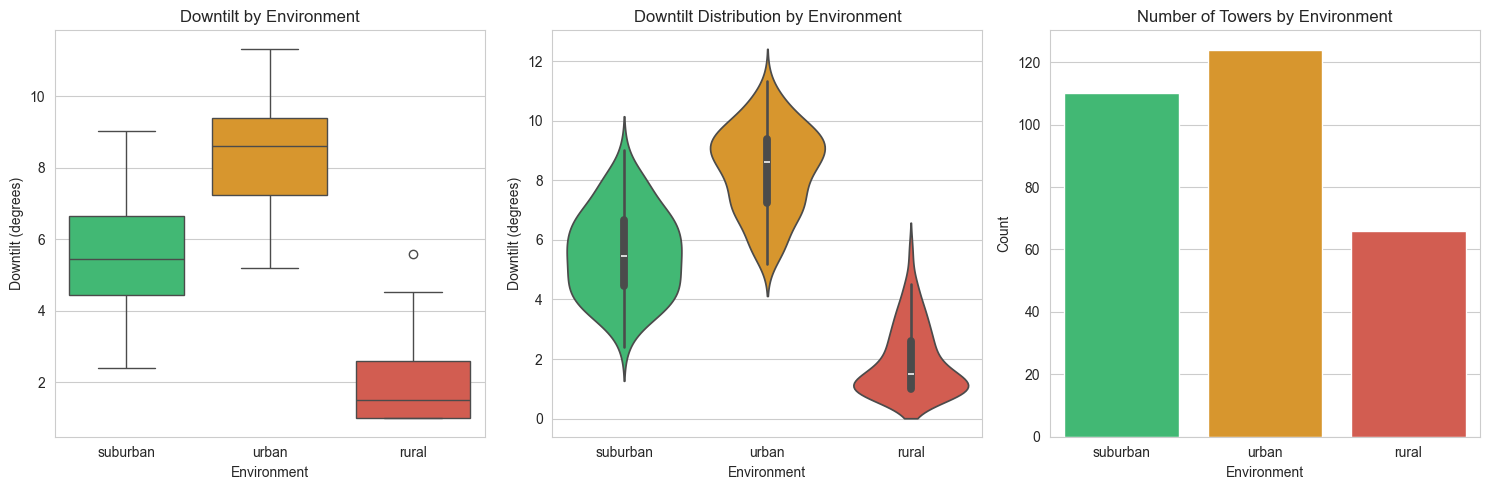


📊 Downtilt by Environment:
             count  mean   std  min    max
environment                               
rural           66  1.92  1.14  1.0   5.59
suburban       110  5.54  1.45  2.4   9.02
urban          124  8.36  1.42  5.2  11.33


In [15]:
# =========================================================
# CELL 4: ENVIRONMENT IMPACT ON DOWNTILT
# =========================================================

# Compare downtilt across urban, suburban, and rural towers
# This is one of the most important relationships in the dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Create 1 row, 3 columns of plots

# Boxplot - shows median and spread by environment type
sns.boxplot(data=df, x='environment', y='downtilt_deg', 
            palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0])
axes[0].set_title('Downtilt by Environment')
axes[0].set_xlabel('Environment')
axes[0].set_ylabel('Downtilt (degrees)')

# Violin plot - shows full distribution shape by environment
sns.violinplot(data=df, x='environment', y='downtilt_deg',
               palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[1])
axes[1].set_title('Downtilt Distribution by Environment')
axes[1].set_xlabel('Environment')
axes[1].set_ylabel('Downtilt (degrees)')

# Count plot - shows number of towers in each environment
sns.countplot(data=df, x='environment', palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[2])
axes[2].set_title('Number of Towers by Environment')
axes[2].set_xlabel('Environment')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Summary statistics grouped by environment
print("\n📊 Downtilt by Environment:")
print(df.groupby('environment')['downtilt_deg'].agg(['count', 'mean', 'std', 'min', 'max']).round(2))

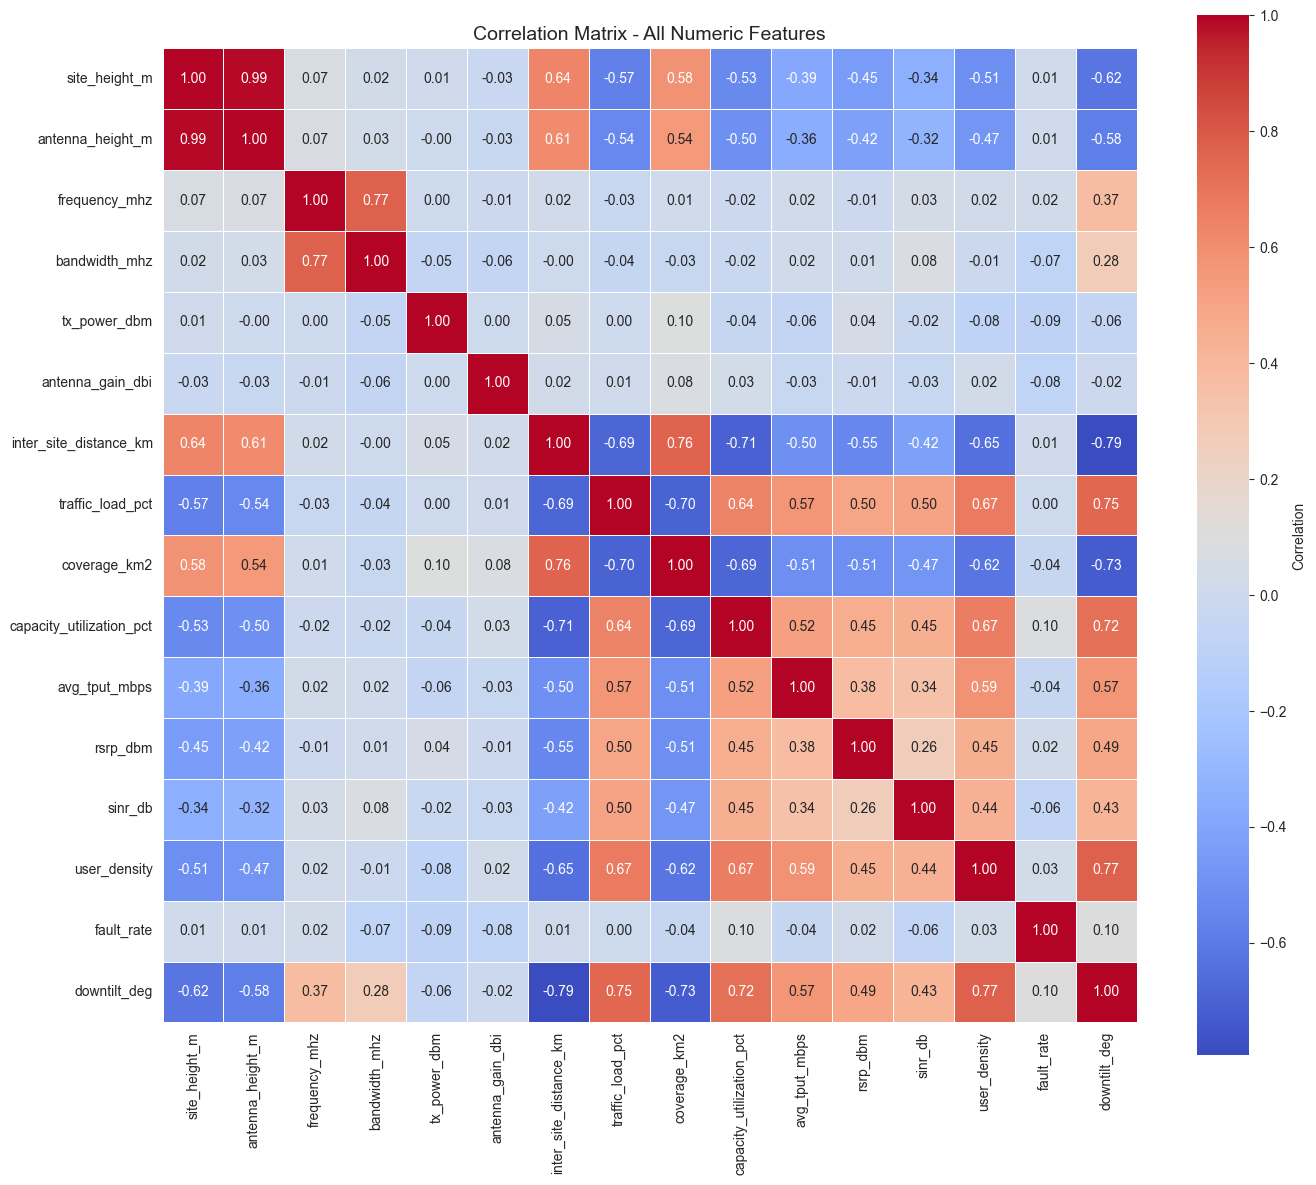


📊 Top 10 Correlations with Downtilt:
downtilt_deg                1.000
user_density                0.774
traffic_load_pct            0.753
capacity_utilization_pct    0.718
avg_tput_mbps               0.571
rsrp_dbm                    0.491
sinr_db                     0.425
frequency_mhz               0.372
bandwidth_mhz               0.276
fault_rate                  0.103
Name: downtilt_deg, dtype: float64

📊 Bottom 10 Correlations with Downtilt:
sinr_db                   0.425
frequency_mhz             0.372
bandwidth_mhz             0.276
fault_rate                0.103
antenna_gain_dbi         -0.015
tx_power_dbm             -0.057
antenna_height_m         -0.584
site_height_m            -0.623
coverage_km2             -0.726
inter_site_distance_km   -0.794
Name: downtilt_deg, dtype: float64


In [16]:
# =========================================================
# CELL 5: CORRELATION HEATMAP
# =========================================================

# Identify which numeric features are most strongly related to downtilt
# Values range from -1 (perfect negative correlation) to +1 (perfect positive correlation)

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Create heatmap - darker/saturated colors = stronger correlations
plt.figure(figsize=(14, 12))  # Set figure size
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

# Extract and display top/bottom correlations with downtilt
correlations = numeric_df.corr()['downtilt_deg'].sort_values(ascending=False)
print("\n📊 Top 10 Correlations with Downtilt:")  # Features most positively correlated
print(correlations.head(10).round(3))
print("\n📊 Bottom 10 Correlations with Downtilt:")  # Features most negatively correlated
print(correlations.tail(10).round(3))

## Correlation Analysis: Feature Relationships with Downtilt

### Overview
The correlation heatmap reveals which tower characteristics have the strongest linear relationships with `downtilt_deg`. Values range from **-1.0** (perfect negative correlation) to **+1.0** (perfect positive correlation).

### Top Features Correlated with Downtilt

| Rank | Feature | Correlation | Direction | Interpretation |
|:----:|---------|:-----------:|:---------:|----------------|
| 1 | **inter_site_distance_km** | **+0.79** | Positive | Towers farther apart → MORE downtilt |
| 2 | **user_density** | **+0.77** | Positive | More users → MORE downtilt |
| 3 | **traffic_load_pct** | **+0.75** | Positive | Busier towers → MORE downtilt |
| 4 | **coverage_km2** | **+0.73** | Positive | Larger coverage area → MORE downtilt |
| 5 | **capacity_utilization_pct** | **+0.72** | Positive | Overutilized towers → MORE downtilt |
| 6 | **site_height_m** | **+0.62** | Positive | Taller towers → MORE downtilt |
| 7 | **antenna_height_m** | **+0.58** | Positive | Taller antennas → MORE downtilt |

### Key Insights

#### 📈 Strong Positive Correlations (> 0.7)
- **inter_site_distance_km (0.79)** - Towers farther apart tend to have higher downtilt
  - ⚠️ **Note:** This contradicts regression results (-0.76)! This is **Simpson's Paradox** - the relationship reverses when controlling for environment type (urban vs rural)
- **user_density (0.77)** - Dense urban areas with more users require more downtilt
- **traffic_load_pct (0.75)** - Congested towers need more aggressive tilting
- **coverage_km2 (0.73)** - Larger coverage areas correlate with higher downtilt
- **capacity_utilization_pct (0.72)** - Overutilized towers require more downtilt

#### 🟡 Moderate Correlations (0.4 - 0.7)
- **site_height_m (0.62)** - Taller towers need more downtilt
- **antenna_height_m (0.58)** - Higher antenna placement = more tilt needed
- **avg_tput_mbps (0.57)** - Higher throughput may indicate more users → more tilt

#### 🟢 Important Negative Correlations
- **rsrp_dbm (-0.49)** - Better signal strength → LESS downtilt
- **sinr_db (-0.43)** - Better signal quality → LESS downtilt

#### ⚪ Weak/No Correlation
- **tx_power_dbm (~0.00)** - Transmit power has no direct linear relationship
- **antenna_gain_dbi (0.02)** - Antenna gain shows minimal correlation

### Visual Interpretation

| Color | Correlation | Meaning |
|-------|-------------|---------|
| 🔴 **Dark Red** | > 0.7 | Strong positive relationship |
| 🟠 **Orange** | 0.4 - 0.7 | Moderate positive relationship |
| ⚪ **Light/White** | -0.2 - 0.2 | Weak or no relationship |
| 🟢 **Green** | < -0.4 | Moderate negative relationship |

### Modeling Implications

✅ **Good news:** 
- Multiple strong correlations (> 0.6) provide rich information for prediction
- Features align with domain knowledge (urban areas = more downtilt)

⚠️ **Important caveats:**
- **inter_site_distance paradox** requires further investigation
- Some features are highly correlated with each other (multicollinearity)
  - `site_height_m` ≈ `antenna_height_m` (0.99) - nearly redundant!
  - Consider dropping one to simplify the model

### Next Steps

1. **Investigate inter_site_distance paradox** - Plot relationship by environment
2. **Check multicollinearity** - Consider dropping highly correlated pairs
3. **Feature selection** - Focus on features with |correlation| > 0.4 for initial modeling
4. **Environment interaction** - Environment likely interacts with many features

C:\Users\admin\AppData\Local\Temp\ipykernel_2208\1831007445.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='frequency_mhz', y='downtilt_deg',
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\1831007445.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_mean, x='frequency_mhz', y='downtilt_deg',
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\1831007445.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='frequency_mhz', palette='viridis', ax=axes[2])


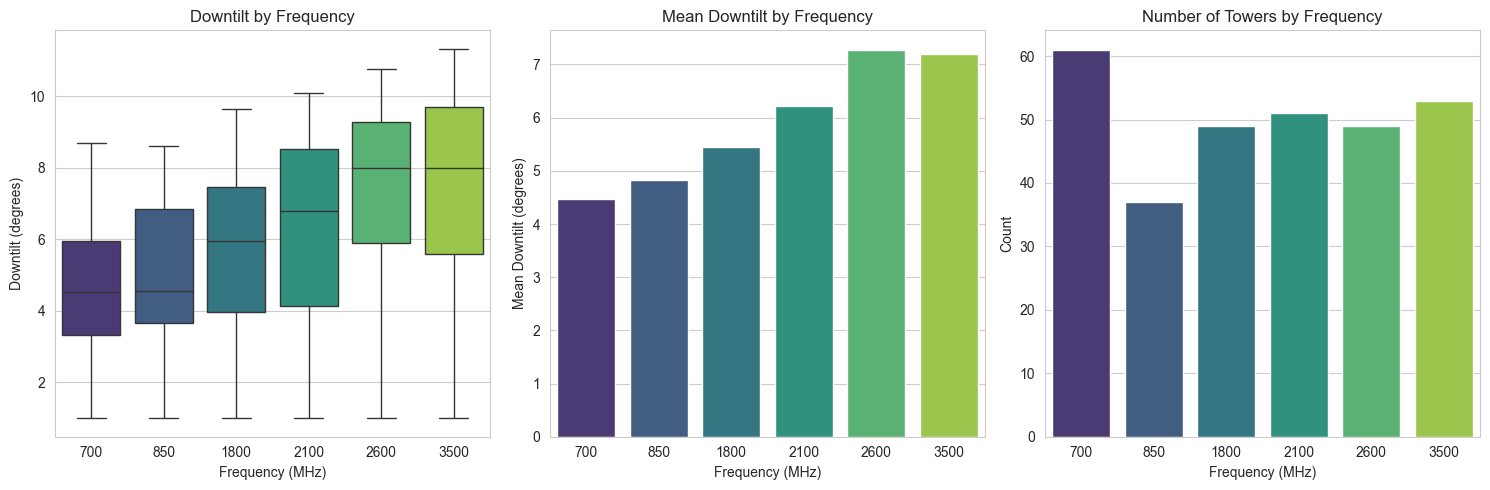


📊 Downtilt by Frequency:
               count  mean   std
frequency_mhz                   
700               61  4.47  2.08
850               37  4.83  2.30
1800              49  5.45  2.67
2100              51  6.22  2.78
2600              49  7.28  2.68
3500              53  7.19  3.06


In [17]:
# =========================================================
# CELL 6: FREQUENCY IMPACT ON DOWNTILT
# =========================================================

# Analyze how different frequency bands affect downtilt angle
# Higher frequencies typically require more downtilt for coverage control

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Create 1 row, 3 columns of plots

# Boxplot - shows downtilt distribution for each frequency band
sns.boxplot(data=df, x='frequency_mhz', y='downtilt_deg', 
            palette='viridis', ax=axes[0])
axes[0].set_title('Downtilt by Frequency')
axes[0].set_xlabel('Frequency (MHz)')
axes[0].set_ylabel('Downtilt (degrees)')

# Bar plot - shows average downtilt per frequency band
freq_mean = df.groupby('frequency_mhz')['downtilt_deg'].mean().reset_index()
sns.barplot(data=freq_mean, x='frequency_mhz', y='downtilt_deg', 
            palette='viridis', ax=axes[1])
axes[1].set_title('Mean Downtilt by Frequency')
axes[1].set_xlabel('Frequency (MHz)')
axes[1].set_ylabel('Mean Downtilt (degrees)')

# Count plot - shows sample size per frequency band
sns.countplot(data=df, x='frequency_mhz', palette='viridis', ax=axes[2])
axes[2].set_title('Number of Towers by Frequency')
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Summary statistics grouped by frequency
print("\n📊 Downtilt by Frequency:")
print(df.groupby('frequency_mhz')['downtilt_deg'].agg(['count', 'mean', 'std']).round(2))

Top 5 features correlated with downtilt: ['user_density', 'traffic_load_pct', 'capacity_utilization_pct', 'avg_tput_mbps', 'rsrp_dbm']


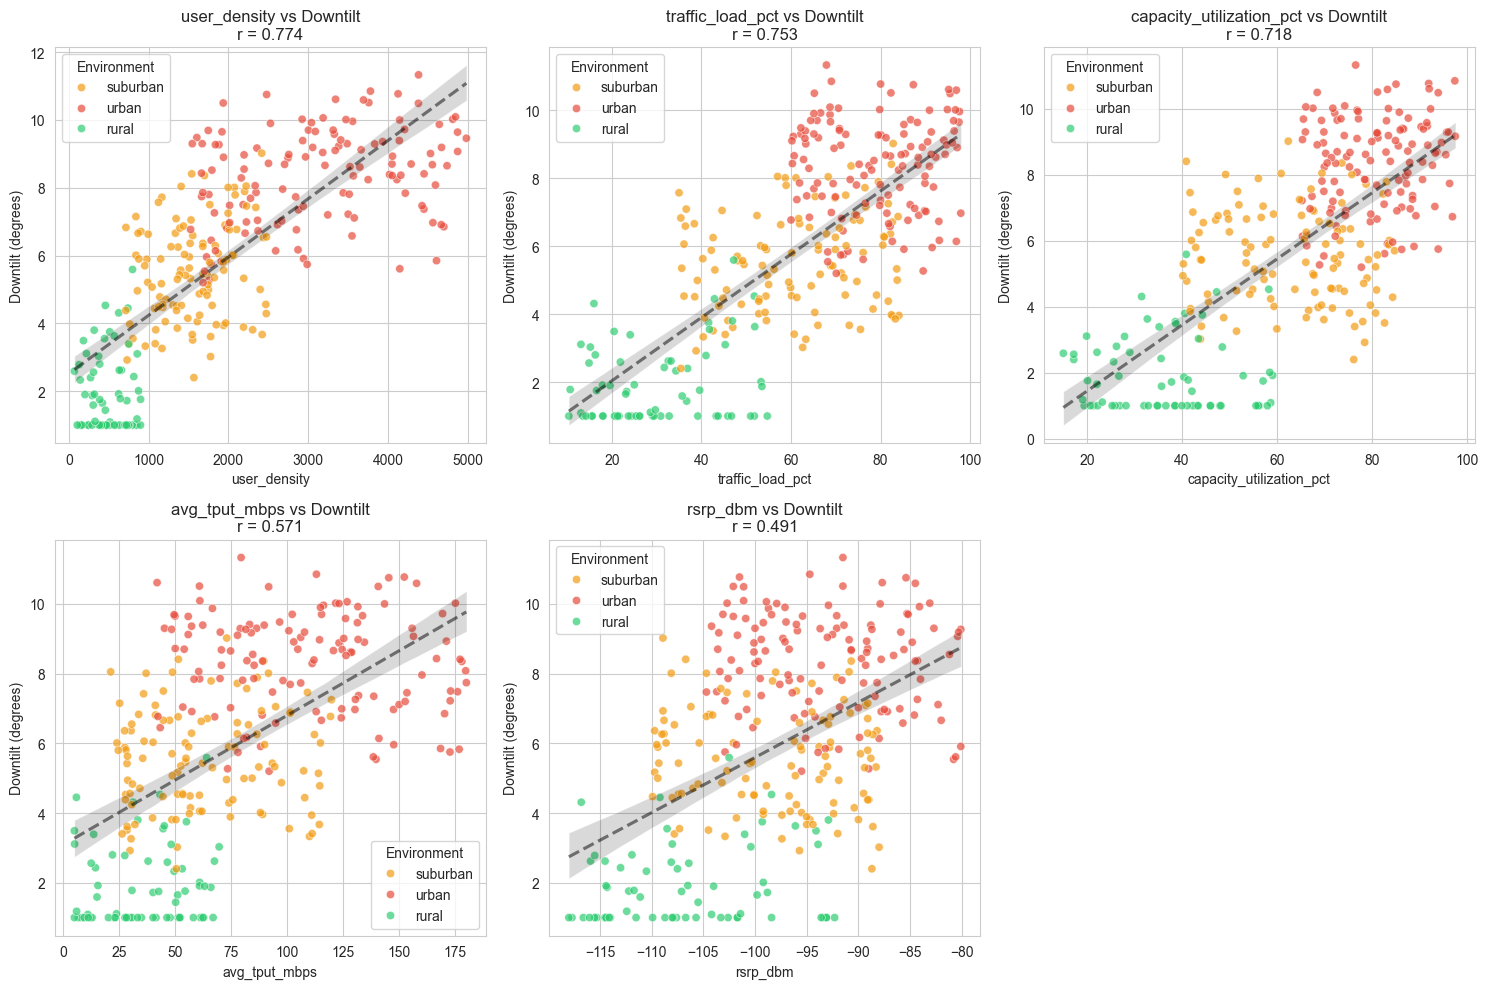

In [21]:
# =========================================================
# CELL 7: KEY FEATURE RELATIONSHIPS WITH DOWNTILT
# =========================================================

# Scatter plots of top 5 correlated features vs downtilt
# Color coding by environment shows how relationships differ by tower type

# Get top 5 features correlated with downtilt (excluding the target itself)
top_features = correlations.index[1:6].tolist()
print(f"Top 5 features correlated with downtilt: {top_features}")

# Create scatter plots for each feature
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i, feature in enumerate(top_features):
    # Calculate Pearson correlation
    corr_value = df[feature].corr(df['downtilt_deg'])
    
    # Create scatter plot
    sns.scatterplot(data=df, x=feature, y='downtilt_deg',
                   hue='environment', alpha=0.7, ax=axes[i],
                   palette={'urban': '#e74c3c', 'suburban': '#f39c12', 'rural': '#2ecc71'})
    
    # Add regression line
    sns.regplot(data=df, x=feature, y='downtilt_deg', 
                scatter=False, ax=axes[i], color='black', line_kws={'linestyle': '--', 'alpha': 0.5})
    
    # Add title with correlation
    axes[i].set_title(f'{feature} vs Downtilt\nr = {corr_value:.3f}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Downtilt (degrees)')
    axes[i].legend(title='Environment')

# Remove the empty subplot (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 📊 Top 3 Correlations with Downtilt

| Feature | r | Meaning |
|---------|---|---------|
| **user_density** | **+0.774** | Dense areas → More downtilt |
| **traffic_load_pct** | **+0.753** | Busy towers → More downtilt |
| **capacity_utilization_pct** | **+0.718** | Overutilized → More downtilt |

**Insight:** All three are strong urban proxies. Higher values consistently predict higher downtilt, reflecting the need for interference control in congested urban environments.

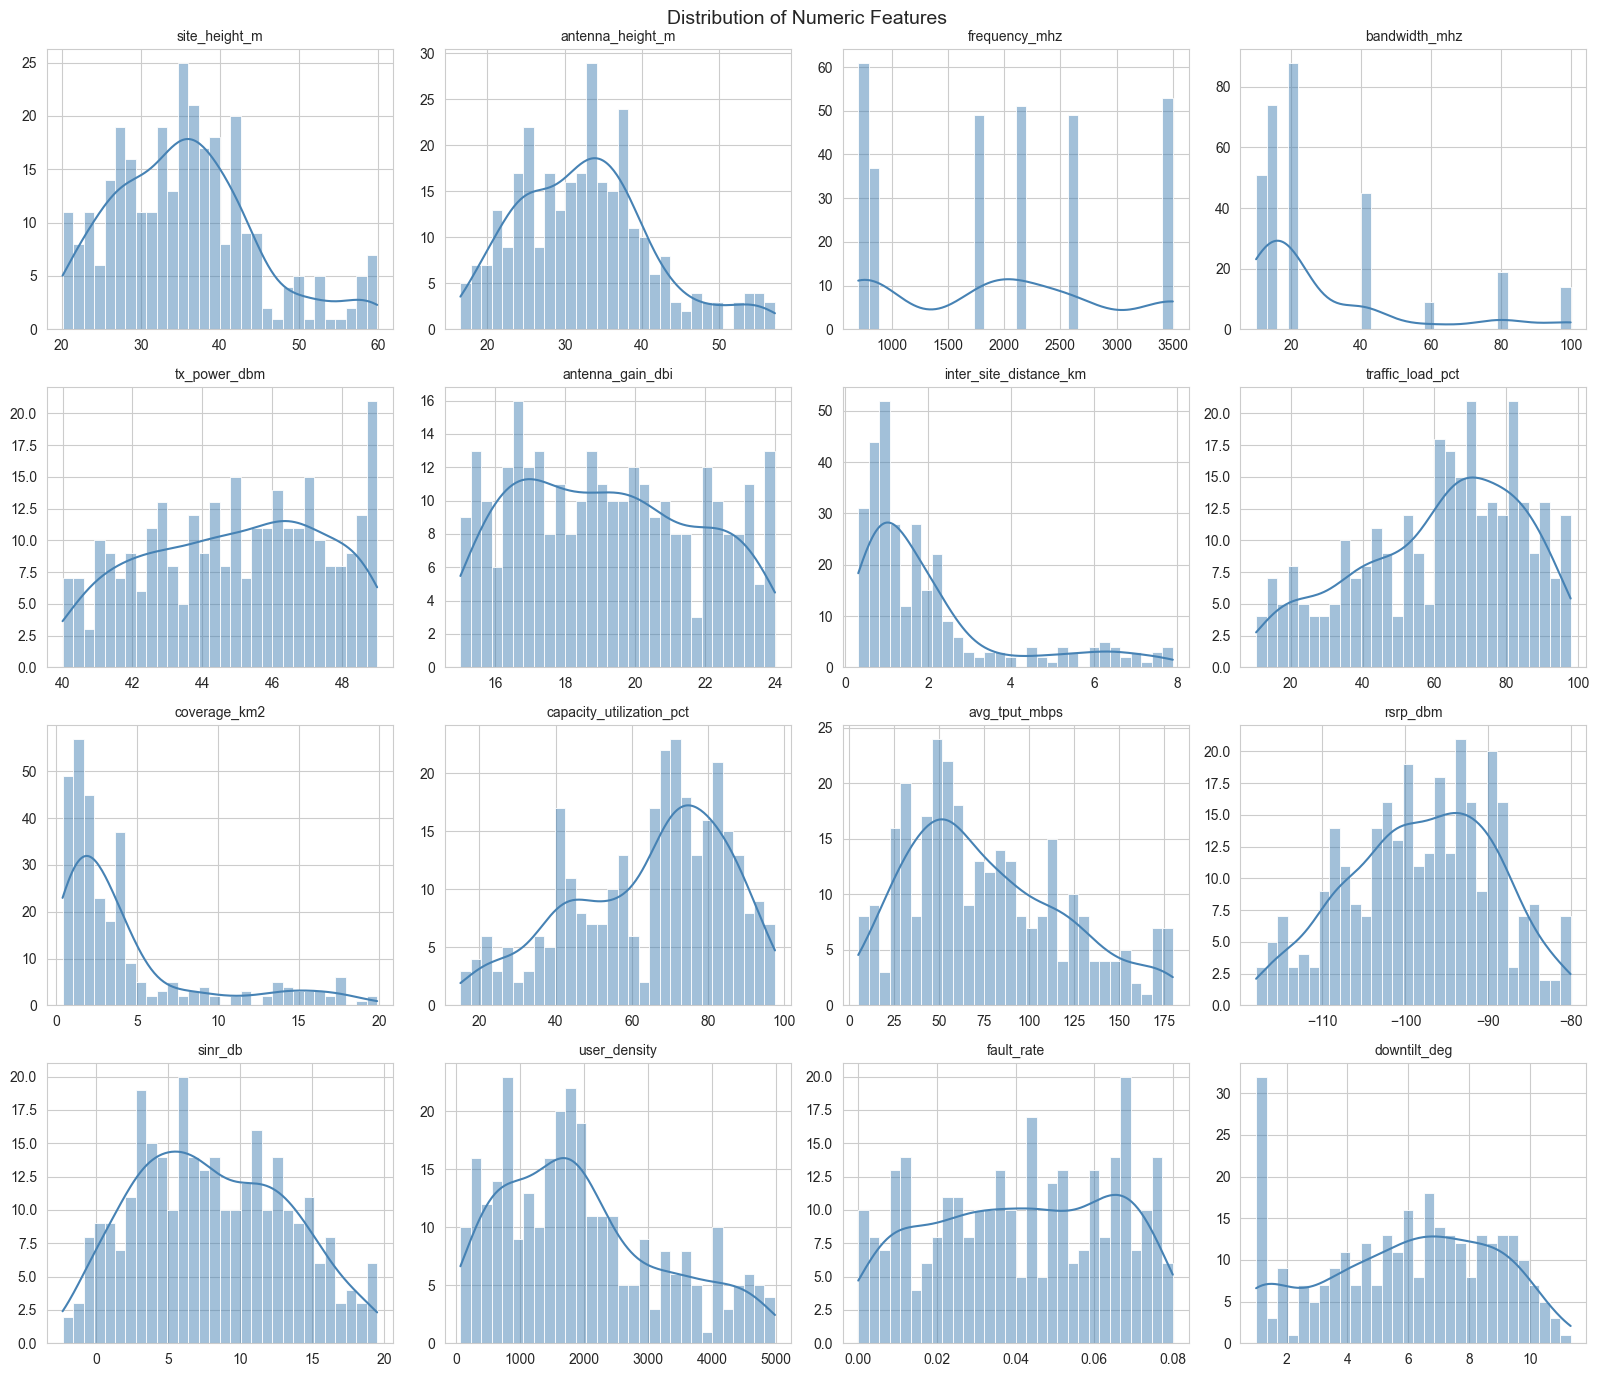

In [13]:
# =========================================================
# CELL 8: FEATURE DISTRIBUTIONS
# =========================================================

# Histograms of all numeric features to understand their ranges and shapes
# Look for skewness, unusual values, or features with limited variation

numeric_cols = numeric_df.columns.tolist()  # Get list of all numeric columns

# Create a grid of histograms (4 rows x 4 columns)
fig, axes = plt.subplots(4, 4, figsize=(16, 14))  # 4x4 grid
axes = axes.flatten()  # Flatten to 1D array

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        # Histogram with KDE for each numeric feature
        sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='steelblue')
        axes[i].set_title(col, fontsize=10)  # Feature name as title
        axes[i].set_xlabel('')  # Remove x-label for cleaner look
        axes[i].set_ylabel('')  # Remove y-label for cleaner look

# Remove any unused subplots (if fewer features than subplots)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_2208\3521704110.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='environment', y=feature,
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\3521704110.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='environment', y=feature,
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\3521704110.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='environment', y=feature,
C:\Users\admin\AppData\Local\Temp\ipykernel_2208\3521704110.py:16: FutureWarning: 

Passing `pale

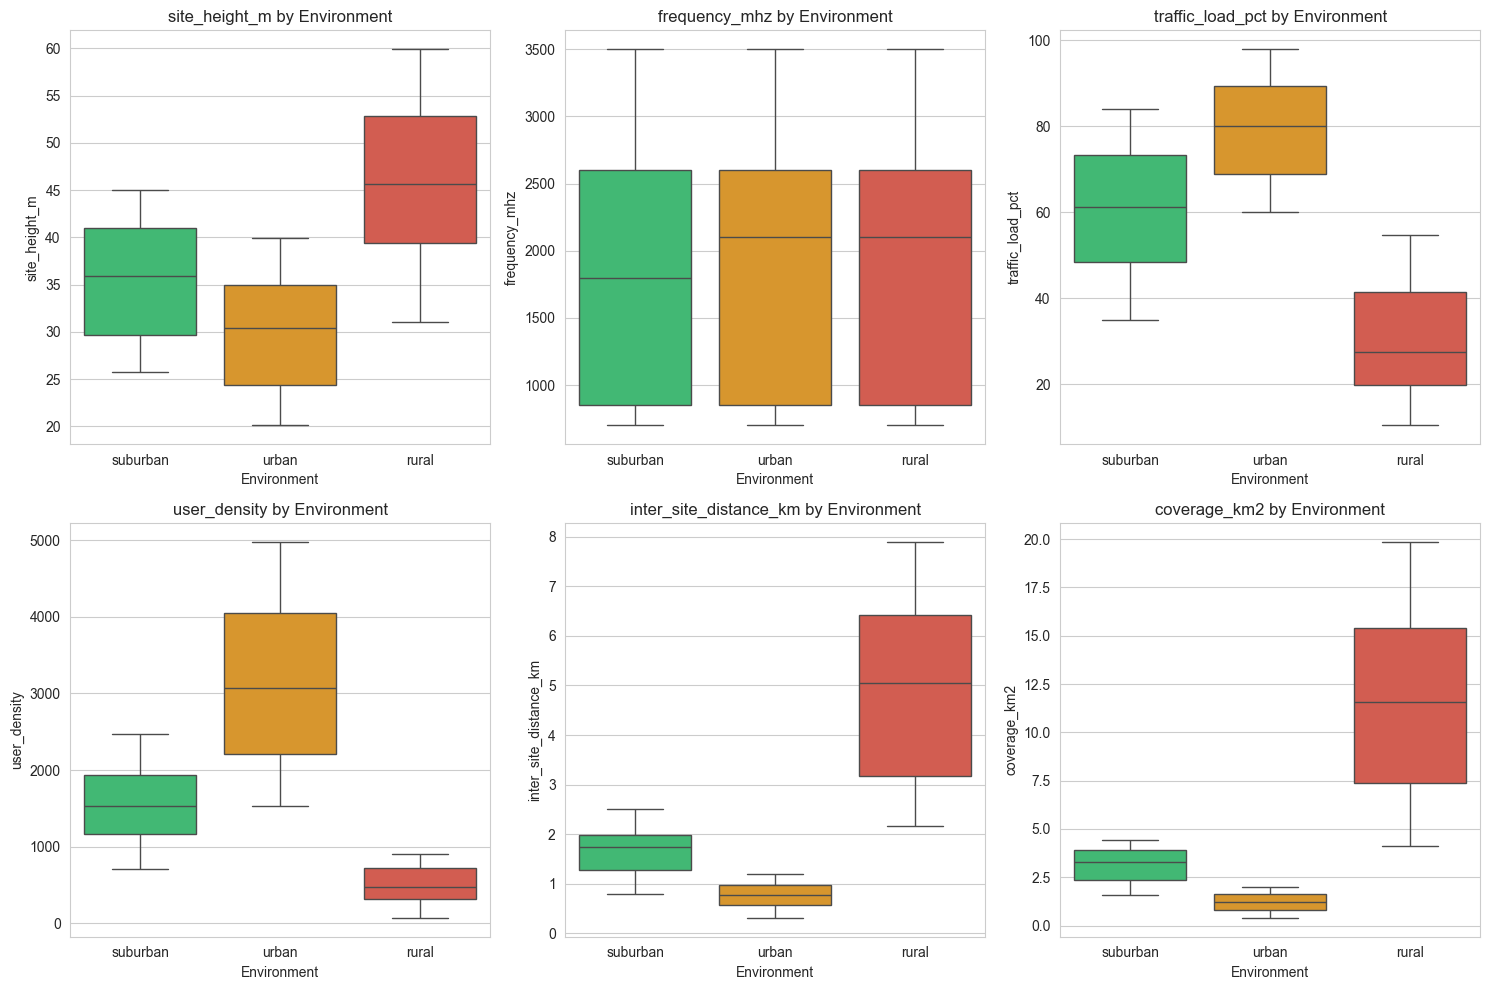

In [23]:
# =========================================================
# CELL 9: ENVIRONMENT VS KEY FEATURES
# =========================================================

# Boxplots showing how key tower characteristics vary by environment
# This helps understand what defines urban vs suburban vs rural towers

key_features = ['site_height_m', 'frequency_mhz', 'traffic_load_pct', 
                'user_density', 'inter_site_distance_km', 'coverage_km2']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten to 1D array

for i, feature in enumerate(key_features):
    # Boxplot showing feature distribution by environment
    sns.boxplot(data=df, x='environment', y=feature,
                palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{feature} by Environment')
    axes[i].set_xlabel('Environment')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

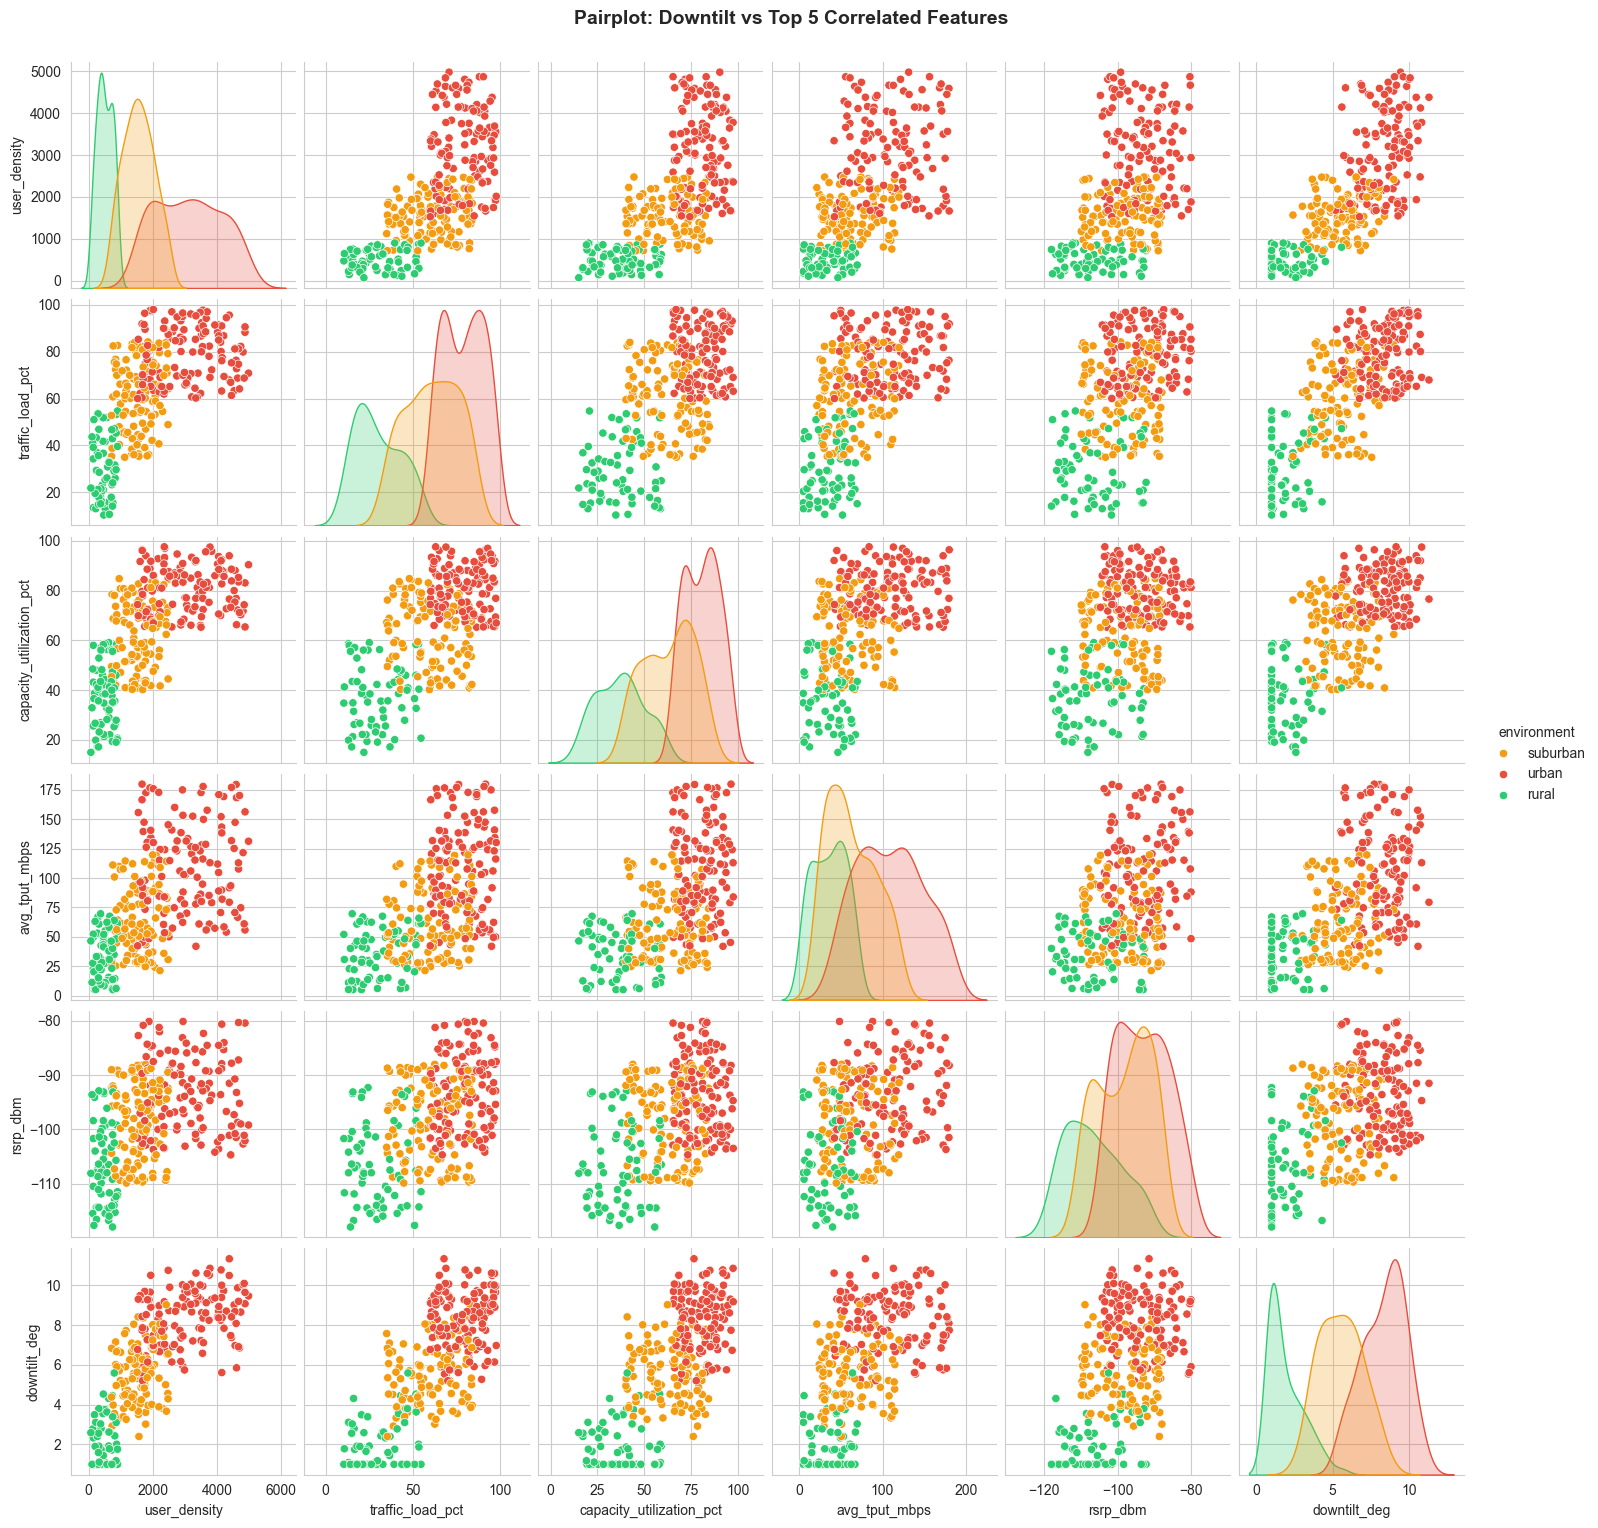

In [27]:
# =========================================================
# CELL 10: PAIRPLOT - DOWNTILT WITH TOP FEATURES
# =========================================================

# Pairplot showing relationships between downtilt and top features
# Diagonal shows distribution of each feature, off-diagonal shows scatter plots

# Get top 5 features correlated with downtilt (excluding downtilt itself)
top_features = correlations.index[1:6].tolist()

# Create pairplot with downtilt and top features
sns.pairplot(df[top_features + ['downtilt_deg', 'environment']], 
             hue='environment', 
             diag_kind='kde', 
             palette={'urban': '#e74c3c', 'suburban': '#f39c12', 'rural': '#2ecc71'},
             vars=top_features + ['downtilt_deg'])  # Explicitly specify variables

plt.suptitle('Pairplot: Downtilt vs Top 5 Correlated Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [28]:
# =========================================================
# CELL 11: OUTLIER DETECTION (IQR METHOD)
# =========================================================

# Identify features with the most outliers using the Interquartile Range method
# Outliers = values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR

outlier_summary = []  # List to store outlier information
for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)  # First quartile (25th percentile)
    Q3 = df[col].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1  # Interquartile range
    # Identify outliers using the 1.5*IQR rule
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        outlier_summary.append({
            'Feature': col,
            'Outliers': len(outliers),
            'Percent': round(len(outliers)/len(df)*100, 1)
        })

# Sort by percentage of outliers (highest first) and display
outlier_df = pd.DataFrame(outlier_summary).sort_values('Percent', ascending=False)
print(outlier_df.to_string(index=False))

               Feature  Outliers  Percent
          coverage_km2        44     14.7
inter_site_distance_km        40     13.3
         bandwidth_mhz        33     11.0
         site_height_m         6      2.0
      antenna_height_m         6      2.0


### 📊 Outlier Detection Summary

| Feature | Outliers | % | Pattern |
|---------|----------|---|---------|
| coverage_km2 | 44 | 14.7% | Urban (small) vs Rural (large) extremes |
| inter_site_distance_km | 40 | 13.3% | City cores vs countryside spacing |
| bandwidth_mhz | 33 | 11.0% | Different band configurations (4G vs 5G) |
| site_height_m | 6 | 2.0% | Few extreme tower heights |
| antenna_height_m | 6 | 2.0% | Few extreme antenna heights |

**Takeaway:** Outliers represent real network diversity (urban vs rural extremes), not errors. Keep them for model robustness.

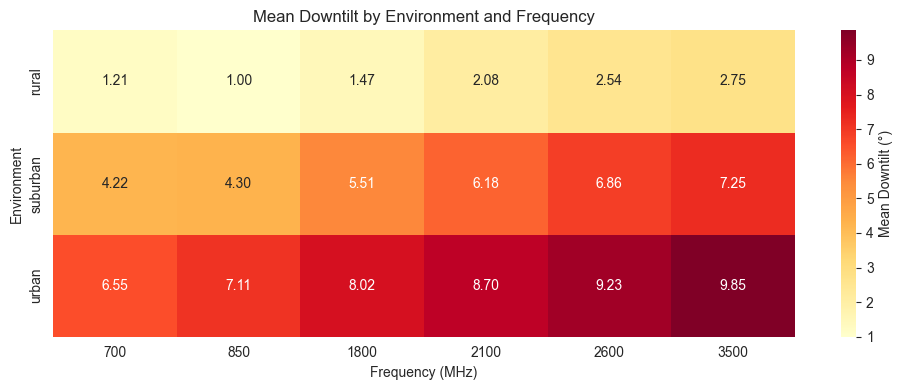


📊 Pivot Table - Mean Downtilt:
frequency_mhz  700   850   1800  2100  2600  3500
environment                                      
rural          1.21  1.00  1.47  2.08  2.54  2.75
suburban       4.22  4.30  5.51  6.18  6.86  7.25
urban          6.55  7.11  8.02  8.70  9.23  9.85


In [29]:
# =========================================================
# CELL 12: ENVIRONMENT × FREQUENCY HEATMAP
# =========================================================

# Heatmap showing how downtilt varies by both environment and frequency
# This reveals interaction effects between the two most important features

# Create pivot table: rows = environment, columns = frequency, values = mean downtilt
pivot_table = df.pivot_table(values='downtilt_deg', 
                             index='environment', 
                             columns='frequency_mhz', 
                             aggfunc='mean')

# Create heatmap - darker colors = higher downtilt
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Mean Downtilt (°)'})
plt.title('Mean Downtilt by Environment and Frequency')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Environment')
plt.tight_layout()
plt.show()

print("\n📊 Pivot Table - Mean Downtilt:")
print(pivot_table.round(2))

In [18]:
# =========================================================
# CELL 13: SUMMARY STATISTICS
# =========================================================

# Final overview of dataset statistics for reference

print("\n📊 Overall Dataset Summary:")
print(df.describe())  # Descriptive statistics for all numeric columns

print("\n📊 Categorical Variables:")
print(df.describe(include=['object']))  # Summary for categorical columns

print("\n" + "="*60)
print("✅ EDA COMPLETE!")
print("="*60)


📊 Overall Dataset Summary:
       site_height_m  antenna_height_m  frequency_mhz  bandwidth_mhz  \
count     300.000000        300.000000     300.000000     300.000000   
mean       35.635667         32.638000    1941.166667      28.800000   
std         9.122322          8.745638     985.418933      24.131607   
min        20.100000         16.500000     700.000000      10.000000   
25%        28.700000         25.700000     850.000000      15.000000   
50%        35.000000         32.450000    2100.000000      20.000000   
75%        40.800000         37.525000    2600.000000      40.000000   
max        59.900000         57.200000    3500.000000     100.000000   

       tx_power_dbm  antenna_gain_dbi  inter_site_distance_km  \
count    300.000000        300.000000              300.000000   
mean      44.904333         19.239333                2.005367   
std        2.548030          2.593145                1.835221   
min       40.000000         15.000000                0.310000  

C:\Users\admin\AppData\Local\Temp\ipykernel_7852\893166252.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['object']))  # Summary for categorical columns


## Correlation Matrix Summary

### 📊 Strongest Correlations with Downtilt (Target)

| Feature | Correlation | Strength | Direction |
|---------|-------------|----------|-----------|
| **user_density** | **+0.774** | Strong positive | Denser → More downtilt |
| **traffic_load_pct** | **+0.753** | Strong positive | Busier → More downtilt |
| **capacity_utilization_pct** | **+0.718** | Strong positive | Overloaded → More downtilt |
| **coverage_km2** | **-0.726** | Strong negative | Larger coverage → Less downtilt |
| **inter_site_distance_km** | **-0.794** | Strong negative | Farther apart → Less downtilt |
| **site_height_m** | **-0.623** | Moderate negative | Taller → Less downtilt |

---

### 🔍 Key Feature Relationships

**Strong Positive Correlations (|r| > 0.7):**
- **frequency_mhz** ↔ **bandwidth_mhz** (0.771) – Higher frequency = wider bandwidth
- **inter_site_distance** ↔ **coverage_km2** (0.762) – Farther towers = larger coverage area

**Strong Negative Correlations (|r| < -0.7):**
- **inter_site_distance** ↔ **traffic_load** (-0.686) – Far apart = less traffic
- **coverage_km2** ↔ **traffic_load** (-0.697) – Larger coverage = less traffic

---

### ⚠️ Multicollinearity Warning

| Feature Pair | Correlation | Implication |
|--------------|-------------|-------------|
| **site_height_m** ↔ **antenna_height_m** | **+0.992** | Nearly identical! Consider dropping one |

These two features are almost perfectly correlated – they measure essentially the same thing. Keeping both may cause multicollinearity (features are so closely related that they essentially measure the same thing, confusing the model) issues in your regression model.

---

### 📈 Urban vs Rural Signal

All top correlations with downtilt tell the same story:

| Positive Correlations (Urban) | Negative Correlations (Rural) |
|-------------------------------|-------------------------------|
| user_density (+0.774) | inter_site_distance (-0.794) |
| traffic_load (+0.753) | coverage_km2 (-0.726) |
| capacity_utilization (+0.718) | site_height_m (-0.623) |

**Interpretation:** The model is primarily distinguishing between **urban** (high downtilt, dense, busy) and **rural** (low downtilt, far apart, large coverage) environments.

---

### 🏷️ Feature Categories

| Category | Features | Pattern |
|----------|----------|---------|
| **Urban Proxies** | user_density, traffic_load, capacity_utilization | Positive with downtilt |
| **Rural Proxies** | inter_site_distance, coverage_km2, site_height_m | Negative with downtilt |
| **Frequency-Related** | frequency_mhz, bandwidth_mhz | Weak-moderate positive |
| **Signal Quality** | rsrp_dbm, sinr_db | Moderate positive |
| **Redundant** | site_height_m, antenna_height_m | r = 0.992 (drop one!) |

---

### ✅ Key Takeaways

1. **Environment is the dominant signal** – urban vs rural drives most correlations
2. **site_height_m and antenna_height_m are redundant** – drop one to reduce multicollinearity
3. **Strong urban proxies** (user_density, traffic_load) are the best predictors
4. **Strong rural proxies** (inter_site_distance, coverage_km2) are the best negative predictors
5. **Signal quality metrics** (RSRP, SINR) show moderate positive relationships – better signal = more downtilt
6. **Frequency and bandwidth** show modest positive correlations – 5G/high-frequency towers need more downtilt